In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

plt.style.use('seaborn-v0_8-muted')
sns.set_context("notebook")

In [32]:
df = pd.read_csv("loan_data.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (45000, 14)
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                 

In [33]:
print("\nNull Values:\n", df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()


Null Values:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

Duplicate Rows: 0


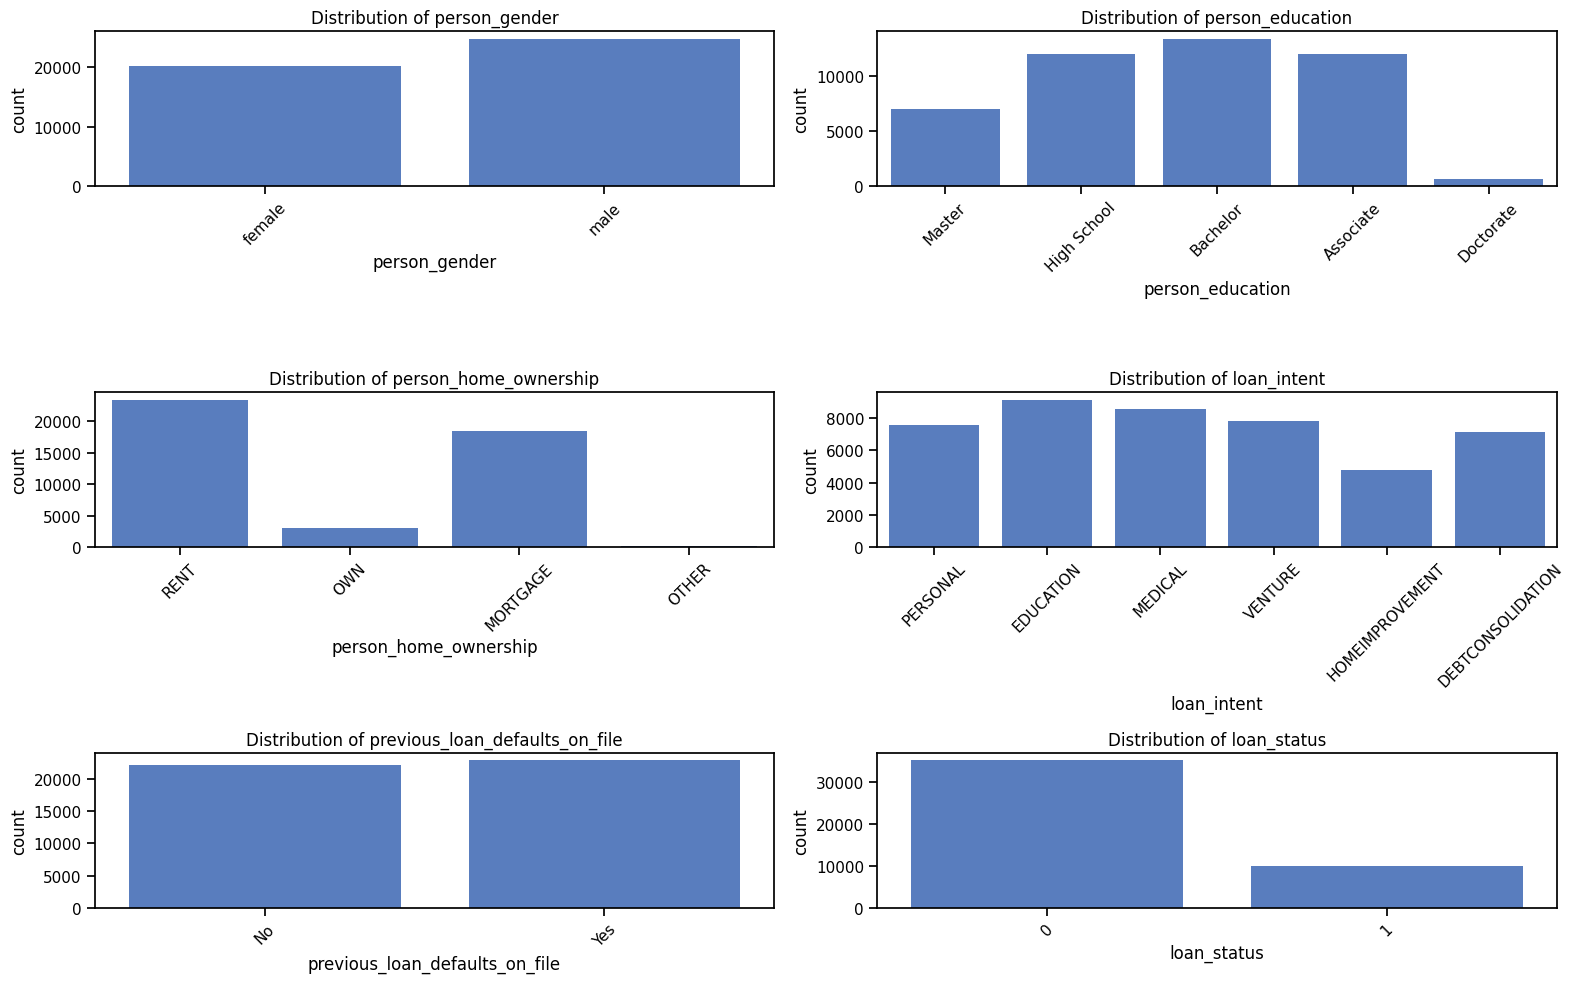

In [34]:
categorical_columns = [
    'person_gender', 'person_education', 'person_home_ownership',
    'loan_intent', 'previous_loan_defaults_on_file', 'loan_status'
]

plt.figure(figsize=(16, 10))

for i, col in enumerate(categorical_columns, 1):
    plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

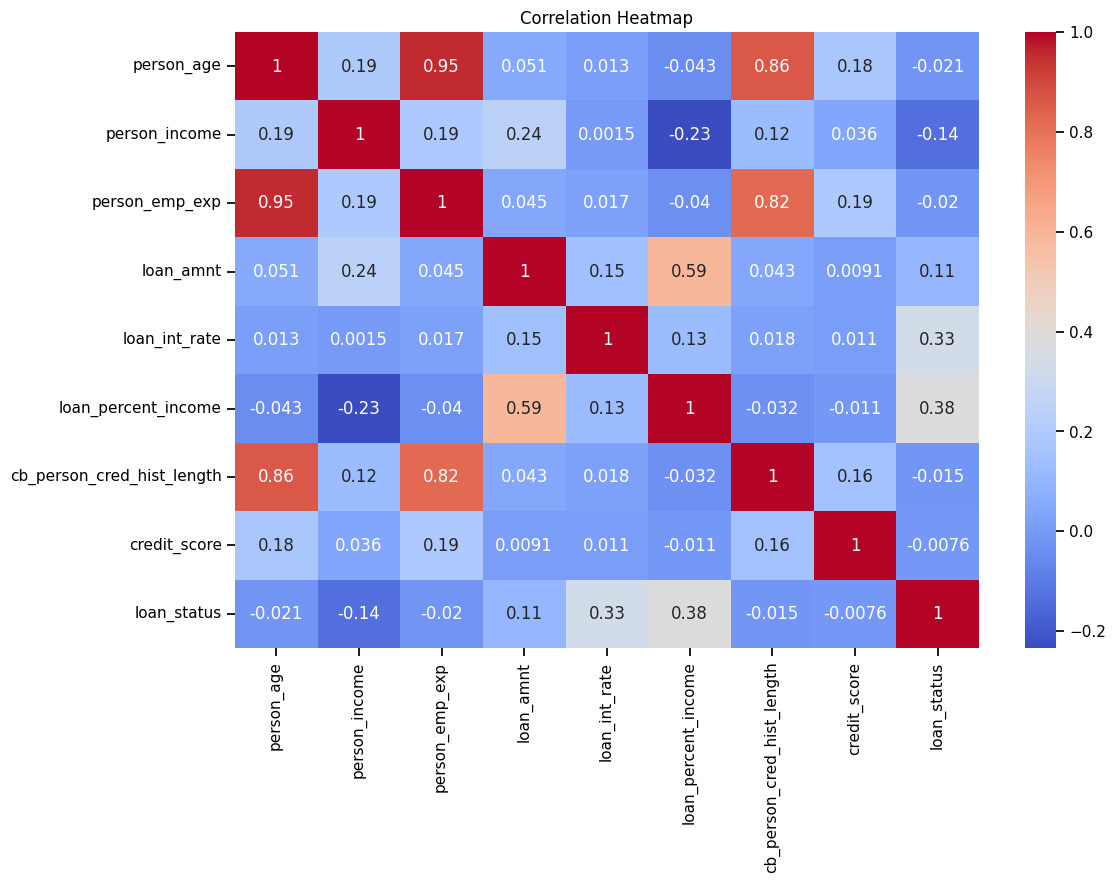

In [35]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [36]:
df_encoded = df.copy()
label_encoders = {}

categorical_features = df.select_dtypes(include='object').columns

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
df_encoded.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,0,4,71948.0,0,3,35000.0,4,16.02,0.49,3.0,561,0,1
1,21.0,0,3,12282.0,0,2,1000.0,1,11.14,0.08,2.0,504,1,0
2,25.0,0,3,12438.0,3,0,5500.0,3,12.87,0.44,3.0,635,0,1
3,23.0,0,1,79753.0,0,3,35000.0,3,15.23,0.44,2.0,675,0,1
4,24.0,1,4,66135.0,1,3,35000.0,3,14.27,0.53,4.0,586,0,1


In [37]:
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss', random_state=42)
}

In [41]:
hybrid_model = VotingClassifier(
    estimators=[
        ('lr', models["Logistic Regression"]),
        ('rf', models["Random Forest"]),
        ('xgb', models["XGBoost"])
    ],
    voting='soft'
)

models["Hybrid Ensemble"] = hybrid_model

In [42]:
results = {}

for name, model in models.items():
    
    model.fit(X_train_scaled, y_train)
    
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc

    print(f"\n{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    print("-"*50)


Logistic Regression Accuracy: 0.8901
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      6990
           1       0.77      0.73      0.75      2010

    accuracy                           0.89      9000
   macro avg       0.84      0.83      0.84      9000
weighted avg       0.89      0.89      0.89      9000

--------------------------------------------------

Random Forest Accuracy: 0.9273
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000

--------------------------------------------------

XGBoost Accuracy: 0.9339
              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6990
           1       0.89      0.81      

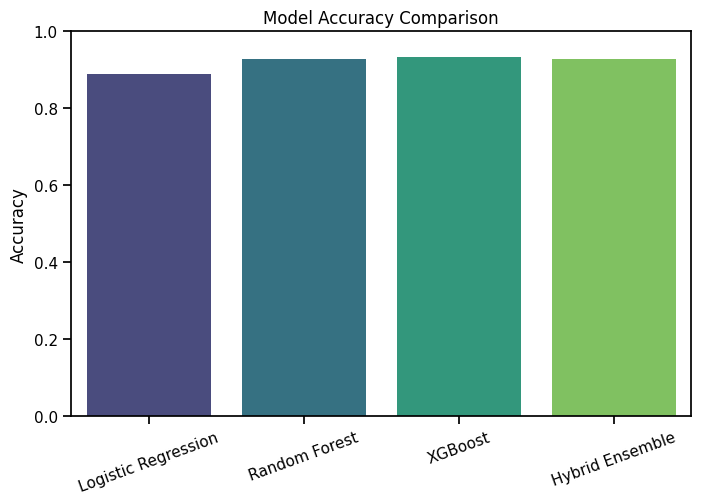

In [43]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    hue=list(results.keys()),
    palette="viridis",
    legend=False
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=20)

plt.show()

In [44]:
best_model_name = max(results, key=results.get)

best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("Best Accuracy:", results[best_model_name])

Best Model: XGBoost
Best Accuracy: 0.9338888888888889


In [45]:
def predict_manual_input():
    
    print(f"\nUsing Best Model: {best_model_name}")
    
    person_age = float(input("Age: "))
    person_gender = input("Gender (male/female): ").lower()
    person_education = input("Education: ").title()
    person_income = float(input("Income: "))
    person_emp_exp = int(input("Employment Experience (years): "))
    person_home_ownership = input("Home Ownership (RENT/OWN/MORTGAGE): ").upper()
    loan_amnt = float(input("Loan Amount: "))
    loan_intent = input("Loan Intent: ").upper()
    loan_int_rate = float(input("Interest Rate (%): "))
    loan_percent_income = float(input("Loan Percent Income: "))
    cb_cred_hist_length = float(input("Credit History Length: "))
    credit_score = int(input("Credit Score: "))
    prev_loan_default = input("Previous Loan Default (Yes/No): ").capitalize()

    input_data = pd.DataFrame([{
        'person_age': person_age,
        'person_gender': label_encoders['person_gender'].transform([person_gender])[0],
        'person_education': label_encoders['person_education'].transform([person_education])[0],
        'person_income': person_income,
        'person_emp_exp': person_emp_exp,
        'person_home_ownership': label_encoders['person_home_ownership'].transform([person_home_ownership])[0],
        'loan_amnt': loan_amnt,
        'loan_intent': label_encoders['loan_intent'].transform([loan_intent])[0],
        'loan_int_rate': loan_int_rate,
        'loan_percent_income': loan_percent_income,
        'cb_person_cred_hist_length': cb_cred_hist_length,
        'credit_score': credit_score,
        'previous_loan_defaults_on_file': label_encoders['previous_loan_defaults_on_file'].transform([prev_loan_default])[0]
    }])

    input_scaled = scaler.transform(input_data)

    prediction = best_model.predict(input_scaled)[0]

    result = "Loan Approved" if prediction == 1 else "Loan Not Approved"

    print("\nPrediction Result:", result)
predict_manual_input()


Using Best Model: XGBoost


ValueError: could not convert string to float: ''

In [ ]:
import pickle

with open("loan_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("label_encoders.pkl", "wb") as f:
    pickle.dump(label_encoders, f)

print("All files saved successfully!")
